<a href="https://colab.research.google.com/github/iav2002/Assignment_Advanced_Topics_In_DeepLearning/blob/main/Part2_Experiments_3(DifferentialLearningRates).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 3 — Differential Learning Rates on ResNet50

Tests whether using different learning rates for the pretrained backbone and the new classification head improves over the uniform-LR full fine-tuning of Variant B in exp1.

 The intuition: the head is initialized randomly and benefits from a higher LR, while the backbone holds delicate pretrained features that need gentler updates. A uniform LR forces a compromise between these two needs.



## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import json, random, time
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')
if device.type == 'cuda':
    print(f'gpu: {torch.cuda.get_device_name(0)}')

Mounted at /content/drive
device: cuda
gpu: NVIDIA A100-SXM4-40GB


## 2. Paths and shared training config

Same training config as Exp 1 and Exp 2 for direct comparison. The 3 LR ratios live in `LR_CONFIGS` so the sweep loop reads from one place.

In [2]:
DRIVE_ROOT = Path('/content/drive/MyDrive/Colab Notebooks/AdvancedDL')
INDEX_DIR = DRIVE_ROOT / 'sample_index'
RESULTS_DIR = DRIVE_ROOT / 'results' / 'exp3_differential_lr'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 128
NUM_WORKERS = 0 # avoiding
NUM_EPOCHS = 20
WEIGHT_DECAY = 1e-4
PATIENCE = 5

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# the 3 LR configurations - head fixed at 1e-3, backbone varies
# label encodes the ratio for easy reading later
LR_CONFIGS = [
    {'label': 'ratio_10x',  'lr_head': 1e-3, 'lr_backbone': 1e-4},
    {'label': 'ratio_20x',  'lr_head': 1e-3, 'lr_backbone': 5e-5},
    {'label': 'ratio_100x', 'lr_head': 1e-3, 'lr_backbone': 1e-5},
]

print(f'results dir: {RESULTS_DIR}')
print(f'configs to test:')
for c in LR_CONFIGS:
    ratio = c['lr_head'] / c['lr_backbone']
    print(f"  {c['label']:12s}: head={c['lr_head']:.0e}, backbone={c['lr_backbone']:.0e} (ratio {ratio:.0f}x)")

results dir: /content/drive/MyDrive/Colab Notebooks/AdvancedDL/results/exp3_differential_lr
configs to test:
  ratio_10x   : head=1e-03, backbone=1e-04 (ratio 10x)
  ratio_20x   : head=1e-03, backbone=5e-05 (ratio 20x)
  ratio_100x  : head=1e-03, backbone=1e-05 (ratio 100x)


## 3. Copy dataset to local SSD + load sample index

Same pipeline as Exp 1 and Exp 2. Skips fast if cache exists.

In [3]:
import shutil

LOCAL_ROOT = Path('/content/dataset_local')
DRIVE_RAW = DRIVE_ROOT / 'raw'
EXPECTED = {'train': 4654, 'val': 1125, 'test': 1124}

def copy_split(split):
    src = DRIVE_RAW / split / 'images'
    dst = LOCAL_ROOT / split / 'images'
    dst.mkdir(parents=True, exist_ok=True)
    if len(list(dst.glob('*.png'))) == EXPECTED[split]:
        print(f'  {split}: already complete')
        return
    print(f'  {split}: copying {EXPECTED[split]} images...')
    t0 = time.time()
    shutil.copytree(src, dst, dirs_exist_ok=True)
    print(f'  {split}: copied in {time.time()-t0:.0f}s')

print('copying dataset to local SSD...')
for split in ['train', 'val', 'test']:
    copy_split(split)
print('done.')

copying dataset to local SSD...
  train: copying 4654 images...
  train: copied in 256s
  val: copying 1125 images...
  val: copied in 99s
  test: copying 1124 images...
  test: copied in 102s
done.


In [4]:
with open(INDEX_DIR / 'samples_train.json') as f: samples_train = json.load(f)
with open(INDEX_DIR / 'samples_val.json') as f:   samples_val = json.load(f)
with open(INDEX_DIR / 'samples_test.json') as f:  samples_test = json.load(f)
with open(INDEX_DIR / 'class_vocab.json') as f:   vocab = json.load(f)

CLASS_TO_IDX = vocab['class_to_idx']
IDX_TO_CLASS = {int(k): v for k, v in vocab['idx_to_class'].items()}
NUM_CLASSES = len(CLASS_TO_IDX)
CLASSES = vocab['keep_classes']

for split_samples in [samples_train, samples_val, samples_test]:
    for s in split_samples:
        s['img_path'] = s['img_path'].replace(str(DRIVE_RAW), str(LOCAL_ROOT))

print(f'classes: {NUM_CLASSES}')
print(f'train: {len(samples_train):,}  val: {len(samples_val):,}  test: {len(samples_test):,}')

classes: 11
train: 11,000  val: 2,750  test: 2,750


## 4. Pre-load to RAM (Copy from previous notebooks)

In [5]:
def preload_to_ram(samples):
    n = len(samples)
    imgs = torch.empty((n, 3, IMG_SIZE, IMG_SIZE), dtype=torch.uint8)
    labels = torch.empty((n,), dtype=torch.long)
    t0 = time.time()
    for i, s in enumerate(samples):
        img = Image.open(s['img_path']).convert('RGB')
        x1, y1, x2, y2 = s['bbox']
        crop = img.crop((x1, y1, x2, y2)).resize((IMG_SIZE, IMG_SIZE))
        imgs[i] = torch.from_numpy(np.asarray(crop)).permute(2, 0, 1)
        labels[i] = s['label']
        if (i+1) % 2000 == 0:
            print(f'  {i+1:,}/{n:,}')
    print(f'done: {n:,} in {time.time()-t0:.0f}s')
    return imgs, labels

class InMemoryDataset(Dataset):
    def __init__(self, imgs, labels):
        self.imgs = imgs; self.labels = labels
        self.mean = torch.tensor(IMAGENET_MEAN).view(3,1,1) * 255
        self.std = torch.tensor(IMAGENET_STD).view(3,1,1) * 255
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        x = self.imgs[i].float()
        return (x - self.mean) / self.std, self.labels[i]

CACHE_DIR = Path('/content/dataset_local')
def preload_or_load(samples, name):
    path = CACHE_DIR / f'preloaded_{name}.pt'
    if path.exists():
        print(f'{name}: loading cache...')
        cache = torch.load(path)
        return cache['imgs'], cache['labels']
    print(f'{name}: preloading...')
    imgs, labels = preload_to_ram(samples)
    torch.save({'imgs': imgs, 'labels': labels}, path)
    return imgs, labels

train_imgs, train_labels = preload_or_load(samples_train, 'train')
val_imgs, val_labels = preload_or_load(samples_val, 'val')
test_imgs, test_labels = preload_or_load(samples_test, 'test')

train_loader = DataLoader(InMemoryDataset(train_imgs, train_labels), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(InMemoryDataset(val_imgs, val_labels),     batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(InMemoryDataset(test_imgs, test_labels),   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f'loaders ready')

train: preloading...


/tmp/ipykernel_943/987304223.py:10: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  imgs[i] = torch.from_numpy(np.asarray(crop)).permute(2, 0, 1)


  2,000/11,000
  4,000/11,000
  6,000/11,000
  8,000/11,000
  10,000/11,000
done: 11,000 in 147s
val: preloading...
  2,000/2,750
done: 2,750 in 37s
test: preloading...
  2,000/2,750
done: 2,750 in 37s
loaders ready


## 5. Shared helpers

Same train/eval loops as previous experiments. The new piece is `make_diff_lr_optimizer`, which builds AdamW with two parameter groups, one for the head (at the high LR) and one for the backbone (at the low LR). PyTorch handles the rest: each param group keeps its own LR through the scheduler.

In [7]:
import torchvision.models as models
from torch.amp import autocast, GradScaler

def build_model(num_classes):
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

def count_trainable(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total

# the key new helper: separate the head's params from the backbone's
# named_parameters lets us route by name - anything starting with "fc" goes to head group
def make_diff_lr_optimizer(model, lr_head, lr_backbone, weight_decay):
    head_params = [p for n, p in model.named_parameters() if n.startswith('fc') and p.requires_grad]
    backbone_params = [p for n, p in model.named_parameters() if not n.startswith('fc') and p.requires_grad]
    optimizer = torch.optim.AdamW([
        {'params': head_params, 'lr': lr_head, 'name': 'head'},
        {'params': backbone_params, 'lr': lr_backbone, 'name': 'backbone'},
    ], weight_decay=weight_decay)
    return optimizer

def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, total_correct, total_n = 0.0, 0, 0
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True); yb = yb.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type='cuda', dtype=torch.float16):
            logits = model(xb)
            loss = criterion(logits, yb)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()
        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(1) == yb).sum().item()
        total_n += xb.size(0)
    return total_loss / total_n, total_correct / total_n

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0
    per_class_correct = torch.zeros(NUM_CLASSES)
    per_class_total = torch.zeros(NUM_CLASSES)
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True); yb = yb.to(device, non_blocking=True)
        with autocast(device_type='cuda', dtype=torch.float16):
            logits = model(xb)
            loss = criterion(logits, yb)
        preds = logits.argmax(1)
        total_loss += loss.item() * xb.size(0)
        total_correct += (preds == yb).sum().item()
        total_n += xb.size(0)
        for c in range(NUM_CLASSES):
            mask = (yb == c)
            per_class_total[c] += mask.sum().item()
            per_class_correct[c] += (preds[mask] == c).sum().item()
    per_class_acc = (per_class_correct / per_class_total.clamp(min=1)).tolist()
    return total_loss / total_n, total_correct / total_n, per_class_acc

print('helpers defined')

helpers defined


## 6. Sanity check — confirm the optimizer has 2 param groups with the right LRs

Build one config and verify the optimizer routes head and backbone correctly.

In [8]:
test_model = build_model(NUM_CLASSES).to(device)
test_optim = make_diff_lr_optimizer(test_model, lr_head=1e-3, lr_backbone=1e-4, weight_decay=WEIGHT_DECAY)

for g in test_optim.param_groups:
    n_params = sum(p.numel() for p in g['params'])
    print(f"  group '{g['name']}': lr={g['lr']:.0e}, params={n_params:,}")

trainable, total = count_trainable(test_model)
print(f'\ntotal trainable: {trainable:,} / {total:,}')

del test_model, test_optim
torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 240MB/s]


  group 'head': lr=1e-03, params=22,539
  group 'backbone': lr=1e-04, params=23,508,032

total trainable: 23,530,571 / 23,530,571


## 7. Training loop over the 3 LR configs

Trains each config sequentially. Same training loop as Exp 1's Variant B — early stopping, best checkpoint, history dump. The scheduler watches val loss and halves *both* param groups' LRs together when it triggers. Per-epoch logs print both LRs separately so the schedule trajectory is visible.

In [9]:
# 15min A100

def train_one_config(config):
    label = config['label']
    print(f'\n{"="*60}\nconfig {label}\n{"="*60}')
    print(f"head lr: {config['lr_head']:.0e}, backbone lr: {config['lr_backbone']:.0e}")

    cfg_dir = RESULTS_DIR / label
    cfg_dir.mkdir(parents=True, exist_ok=True)

    model = build_model(NUM_CLASSES).to(device)
    # everything is trainable - this is full fine-tuning, just with split LRs
    optimizer = make_diff_lr_optimizer(model, config['lr_head'], config['lr_backbone'], WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    criterion = nn.CrossEntropyLoss()
    scaler = GradScaler()

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
               'lr_head': [], 'lr_backbone': [], 'per_class_val_acc': [],
               'config': config}
    best_val_loss = float('inf')
    epochs_no_improve = 0
    t0 = time.time()
    ckpt_path = cfg_dir / 'best.pt'

    for epoch in range(NUM_EPOCHS):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
        val_loss, val_acc, per_class_acc = evaluate(model, val_loader, criterion)
        scheduler.step(val_loss)

        # both param groups get halved together by ReduceLROnPlateau
        # we log them separately so we can see the trajectory of each
        lr_head = optimizer.param_groups[0]['lr']
        lr_backbone = optimizer.param_groups[1]['lr']

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr_head'].append(lr_head)
        history['lr_backbone'].append(lr_backbone)
        history['per_class_val_acc'].append(per_class_acc)

        elapsed = (time.time() - t0) / 60
        print(f'  epoch {epoch:2d} | train {tr_loss:.4f}/{tr_acc:.4f} | '
              f'val {val_loss:.4f}/{val_acc:.4f} | '
              f'lr h={lr_head:.0e} b={lr_backbone:.0e} | {elapsed:.1f} min')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save({'model_state': model.state_dict(),
                        'epoch': epoch, 'val_loss': val_loss, 'val_acc': val_acc,
                        'config': config}, ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f'  early stopping at epoch {epoch}')
                break

    history['total_time_min'] = (time.time() - t0) / 60

    # final test eval on best checkpoint
    ckpt = torch.load(ckpt_path)
    model.load_state_dict(ckpt['model_state'])
    test_loss, test_acc, test_per_class = evaluate(model, test_loader, criterion)
    history['test_loss'] = test_loss
    history['test_acc'] = test_acc
    history['test_per_class_acc'] = test_per_class

    with open(cfg_dir / 'history.json', 'w') as f:
        json.dump(history, f, indent=2)

    print(f'  test acc: {test_acc:.4f} | time: {history["total_time_min"]:.1f} min')
    del model
    torch.cuda.empty_cache()
    return history

all_histories = {}
for config in LR_CONFIGS:
    all_histories[config['label']] = train_one_config(config)

print('\nall configs done')# expected ~5 min per config, ~15 min total

def train_one_config(config):
    label = config['label']
    print(f'\n{"="*60}\nconfig {label}\n{"="*60}')
    print(f"head lr: {config['lr_head']:.0e}, backbone lr: {config['lr_backbone']:.0e}")

    cfg_dir = RESULTS_DIR / label
    cfg_dir.mkdir(parents=True, exist_ok=True)

    model = build_model(NUM_CLASSES).to(device)
    # everything is trainable - this is full fine-tuning, just with split LRs
    optimizer = make_diff_lr_optimizer(model, config['lr_head'], config['lr_backbone'], WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    criterion = nn.CrossEntropyLoss()
    scaler = GradScaler()

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
               'lr_head': [], 'lr_backbone': [], 'per_class_val_acc': [],
               'config': config}
    best_val_loss = float('inf')
    epochs_no_improve = 0
    t0 = time.time()
    ckpt_path = cfg_dir / 'best.pt'

    for epoch in range(NUM_EPOCHS):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
        val_loss, val_acc, per_class_acc = evaluate(model, val_loader, criterion)
        scheduler.step(val_loss)

        # both param groups get halved together by ReduceLROnPlateau
        # we log them separately so we can see the trajectory of each
        lr_head = optimizer.param_groups[0]['lr']
        lr_backbone = optimizer.param_groups[1]['lr']

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr_head'].append(lr_head)
        history['lr_backbone'].append(lr_backbone)
        history['per_class_val_acc'].append(per_class_acc)

        elapsed = (time.time() - t0) / 60
        print(f'  epoch {epoch:2d} | train {tr_loss:.4f}/{tr_acc:.4f} | '
              f'val {val_loss:.4f}/{val_acc:.4f} | '
              f'lr h={lr_head:.0e} b={lr_backbone:.0e} | {elapsed:.1f} min')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save({'model_state': model.state_dict(),
                        'epoch': epoch, 'val_loss': val_loss, 'val_acc': val_acc,
                        'config': config}, ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f'  early stopping at epoch {epoch}')
                break

    history['total_time_min'] = (time.time() - t0) / 60

    # final test eval on best checkpoint
    ckpt = torch.load(ckpt_path)
    model.load_state_dict(ckpt['model_state'])
    test_loss, test_acc, test_per_class = evaluate(model, test_loader, criterion)
    history['test_loss'] = test_loss
    history['test_acc'] = test_acc
    history['test_per_class_acc'] = test_per_class

    with open(cfg_dir / 'history.json', 'w') as f:
        json.dump(history, f, indent=2)

    print(f'  test acc: {test_acc:.4f} | time: {history["total_time_min"]:.1f} min')
    del model
    torch.cuda.empty_cache()
    return history

all_histories = {}
for config in LR_CONFIGS:
    all_histories[config['label']] = train_one_config(config)

print('\nall configs done')


config ratio_10x
head lr: 1e-03, backbone lr: 1e-04
  epoch  0 | train 0.4418/0.8808 | val 0.0756/0.9745 | lr h=1e-03 b=1e-04 | 0.3 min
  epoch  1 | train 0.0220/0.9945 | val 0.0438/0.9865 | lr h=1e-03 b=1e-04 | 0.5 min
  epoch  2 | train 0.0049/0.9994 | val 0.0392/0.9884 | lr h=1e-03 b=1e-04 | 0.7 min
  epoch  3 | train 0.0030/0.9995 | val 0.0532/0.9862 | lr h=1e-03 b=1e-04 | 0.9 min
  epoch  4 | train 0.0008/1.0000 | val 0.0473/0.9880 | lr h=1e-03 b=1e-04 | 1.2 min
  epoch  5 | train 0.0004/1.0000 | val 0.0459/0.9876 | lr h=5e-04 b=5e-05 | 1.4 min
  epoch  6 | train 0.0003/1.0000 | val 0.0459/0.9880 | lr h=5e-04 b=5e-05 | 1.6 min
  epoch  7 | train 0.0003/1.0000 | val 0.0450/0.9895 | lr h=5e-04 b=5e-05 | 1.8 min
  early stopping at epoch 7
  test acc: 0.9862 | time: 1.8 min

config ratio_20x
head lr: 1e-03, backbone lr: 5e-05
  epoch  0 | train 0.5740/0.8503 | val 0.1059/0.9698 | lr h=1e-03 b=5e-05 | 0.2 min
  epoch  1 | train 0.0421/0.9907 | val 0.0680/0.9807 | lr h=1e-03 b=5e-05 |

## 8. Comparison across configs

Plots val loss and val acc for all 3 configs overlaid. Summary table compares test acc, best epoch, and time. The interesting question is whether the 100x ratio (very gentle on backbone) matches or beats the 10x ratio (more standard).

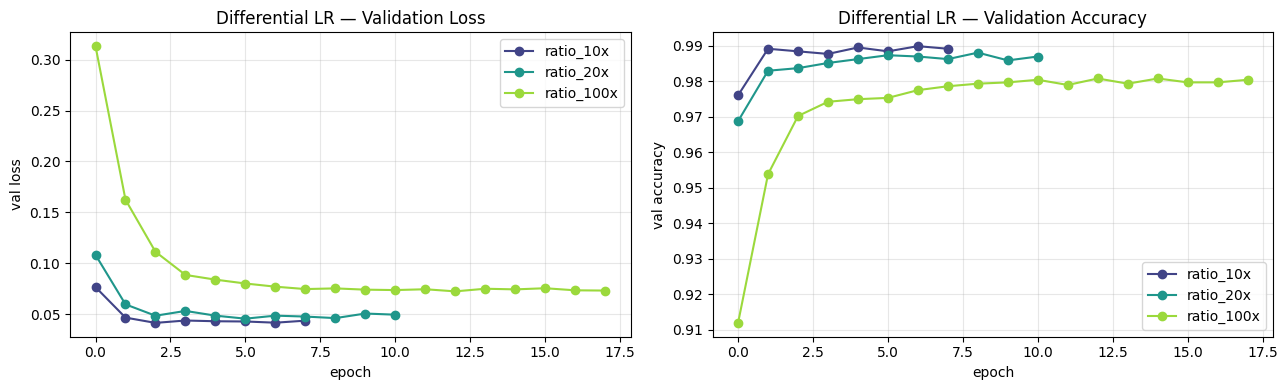


        config   head lr     bb lr  ratio   test acc  test loss  time (min)
--------------------------------------------------------------------------------
     ratio_10x     1e-03     1e-04    10x     0.9865     0.0517         1.7
     ratio_20x     1e-03     5e-05    20x     0.9840     0.0626         2.4
    ratio_100x     1e-03     1e-05   100x     0.9756     0.0888         4.0

per-class test accuracy by config:
class              ratio_10x    ratio_20x   ratio_100x
------------------------------------------------------
box                    0.992        0.984        0.984
ceiling                0.996        0.988        0.992
floor                  0.984        0.984        0.984
floor_decal            0.996        1.000        0.996
lamp                   0.996        1.000        0.972
pallet                 0.996        0.992        0.976
pillar                 0.992        0.984        0.964
rack                   0.972        0.968        0.972
sign                   1.000

In [10]:
labels_to_show = [c['label'] for c in LR_CONFIGS]
hist = {}
for lbl in labels_to_show:
    with open(RESULTS_DIR / lbl / 'history.json') as f:
        hist[lbl] = json.load(f)

colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(labels_to_show)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for lbl, color in zip(labels_to_show, colors):
    epochs_run = range(len(hist[lbl]['val_loss']))
    axes[0].plot(epochs_run, hist[lbl]['val_loss'], label=lbl, color=color, marker='o')
    axes[1].plot(epochs_run, hist[lbl]['val_acc'],  label=lbl, color=color, marker='o')

axes[0].set_xlabel('epoch'); axes[0].set_ylabel('val loss')
axes[0].set_title('Differential LR — Validation Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('val accuracy')
axes[1].set_title('Differential LR — Validation Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'comparison_curves.png', dpi=120)
plt.show()

# summary table
print(f'\n{"config":>14}  {"head lr":>8}  {"bb lr":>8}  {"ratio":>5}  {"test acc":>9}  {"test loss":>9}  {"time (min)":>10}')
print('-' * 80)
for lbl in labels_to_show:
    h = hist[lbl]
    c = h['config']
    ratio = c['lr_head'] / c['lr_backbone']
    print(f'{lbl:>14}  {c["lr_head"]:>8.0e}  {c["lr_backbone"]:>8.0e}  '
          f'{ratio:>4.0f}x  {h["test_acc"]:>9.4f}  {h["test_loss"]:>9.4f}  '
          f'{h["total_time_min"]:>10.1f}')

# per-class test acc
print(f'\nper-class test accuracy by config:')
header = f'{"class":15s}  ' + '  '.join(f'{lbl:>11}' for lbl in labels_to_show)
print(header); print('-' * len(header))
for cls, idx in sorted(CLASS_TO_IDX.items(), key=lambda x: x[1]):
    row = f'{cls:15s}  ' + '  '.join(f'{hist[lbl]["test_per_class_acc"][idx]:>11.3f}' for lbl in labels_to_show)
    print(row)

## 9. Comparison against Variant B from Gradual Unfreezing

Variant B used uniform LR 1e-4 throughout. The question this experiment answers: does splitting the LR earn anything over that uniform baseline?

**Result:** No. All three differential LR configs underperformed Variant B, and the gap grew monotonically with the ratio (10x: −0.18, 20x: −0.44, 100x: −1.27). The reason traces back to Experiment 1: most of B's accuracy gain over A came from backbone adaptation, not from head training.

 Differential LR's high ratios constrain exactly that adaptation. The technique is sound and well-implemented; it is the assumption it relies on (pretrained features should be preserved more than adapted) that does not hold for this dataset.

In [11]:
exp1_dir = DRIVE_ROOT / 'results' / 'exp1_gradual_unfreezing'
with open(exp1_dir / 'exp1_B' / 'history.json') as f:
    variant_B = json.load(f)

print(f'{"method":35s}  {"head lr":>8}  {"bb lr":>8}  {"test acc":>9}')
print('-' * 70)
print(f'{"Variant B (uniform 1e-4)":35s}  {"1e-04":>8}  {"1e-04":>8}  {variant_B["test_acc"]:>9.4f}')
for lbl in labels_to_show:
    h = hist[lbl]
    c = h['config']
    name = f'Diff LR {lbl}'
    print(f'{name:35s}  {c["lr_head"]:>8.0e}  {c["lr_backbone"]:>8.0e}  {h["test_acc"]:>9.4f}')

# delta vs B for clarity
print(f'\ndelta vs Variant B (uniform):')
for lbl in labels_to_show:
    delta = hist[lbl]['test_acc'] - variant_B['test_acc']
    sign = '+' if delta >= 0 else ''
    print(f'  {lbl:14s}: {sign}{delta*100:.2f} points')

method                                head lr     bb lr   test acc
----------------------------------------------------------------------
Variant B (uniform 1e-4)                1e-04     1e-04     0.9884
Diff LR ratio_10x                       1e-03     1e-04     0.9865
Diff LR ratio_20x                       1e-03     5e-05     0.9840
Diff LR ratio_100x                      1e-03     1e-05     0.9756

delta vs Variant B (uniform):
  ratio_10x     : -0.18 points
  ratio_20x     : -0.44 points
  ratio_100x    : -1.27 points
